In [1]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

from hubble_fit import *

In [2]:

# Load Pantheon+ SN metadata
print("Loading Pantheon+ supernova data...")
df_pantheon = pd.read_csv(
    #"https://raw.githubusercontent.com/PantheonPlusSH0ES/DataRelease/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES.dat",
    "data/Pantheon+SH0ES.dat",
    sep=r"\s+"
)

print("Loading SN covariance matrix...")
n_sn = len(df_pantheon)

# Load .cov file with NumPy, skipping the first line (which contains just "1701")
cov_flat = np.loadtxt(
    #"https://raw.githubusercontent.com/PantheonPlusSH0ES/DataRelease/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES_STAT%2BSYS.cov",
    "data/Pantheon+SH0ES_STAT+SYS.cov",
    skiprows=1
)

# Reshape into square matrix
cov_matrix = cov_flat.reshape((n_sn, n_sn))

# Confirm shape is correct
assert cov_matrix.shape == (n_sn, n_sn), f"Expected ({n_sn},{n_sn}), got {cov_matrix.shape}"

# Invert covariance and pre-compute log-determinant for SN likelihood
global Cov_inv, logdetCov
Cov_inv = np.linalg.inv(cov_matrix)
sign, logdet = np.linalg.slogdet(cov_matrix)
if sign <= 0:
    raise ValueError("Covariance matrix is not positive-definite!")
logdetCov = logdet
print("Data loaded. Running joint cosmographic fits...")


Loading Pantheon+ supernova data...
Loading SN covariance matrix...
Data loaded. Running joint cosmographic fits...


In [3]:
df_agn = load_quasar_data("data/june1_joint_N20w2000s1000_fits_merged.h5", populate_sdss=False)


Reading quasars from HDF5: 100%|██████████| 2753/2753 [00:07<00:00, 381.89it/s]


Number of quasars loaded: 2753
Before dropping NaNs and infs, number of quasars: 2753
Number of quasars with 0 < z <= 0.5: 101
Number of quasars with z > 3: 51
Columns with NaNs: []
Before data cuts, number of quasars: 2753
Number of quasars with 0 < z <= 0.5: 101
Number of quasars with z > 3: 51
Number of quasars with 0 < z <= 0.5: 92
Number of dropped quasars with 0 < z <= 0.5: 9
Number of quasars with z > 3: 51
Final number of quasars: 2662


In [4]:
import hubble_fit
cosmo_model = 'FlatwCDM'
sampler, flat_samples, labels, mag_corr, logZ, logZerr = hubble_fit.run_mcmc_pipeline(df_agn, df_pantheon, fitting_method='dynesty', cosmo_model=cosmo_model,
                                                                                      completeness=True, use_full_cov=False,)


log tau UV RF pivot:  3.0588369242628093
log sigma hat sq pivot:  -1.3452266350760789
alpha_nu pivot:  nan
z mean: 1.550,  z_agn_pivot: 1.471


/opt/miniconda3/envs/jaxgpu/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:568: RuntimeWarning: invalid value encountered in multiply
  avg = avg_as_array = np.multiply(a, wgt,


Fraction of finite likelihoods: 1.0


3133it [01:42, 30.65it/s, batch: 1 | bound: 108 | nc: 1 | ncall: 113435 | eff(%):  2.761 | loglstar: -7667.820 < -5389.087 <    inf | logz: -7003.251 +/-  1.978 | stop: 10.000]     



Bayesian evidence logZ = -5426.60 ± 0.68
Dynesty results stats:
  samples shape: (3133, 14)
  weights max: 0.0022699801608531823
  effective samples: 656.1973727844413
       gamma_sn: -0.0025 (+0.0113, -0.0111)
         tau_Ms: 0.0987 (+0.0644, -0.0537)
          M0_sn: -19.2512 (+0.0438, -0.0390)
         M0_agn: -21.5347 (+0.0810, -0.0861)
log_sigma_hat_sq_break: -1.1649 (+0.0310, -0.0325)
     eta_A1_agn: 2.6737 (+0.0916, -0.1001)
     eta_A2_agn: 1.4703 (+0.1173, -0.1169)
  eta_break_agn: 8.8884 (+0.7803, -1.4395)
       beta_agn: -1.3299 (+0.0777, -0.0730)
      gamma_agn: -0.6129 (+0.0295, -0.0250)
          log_f: 0.0500 (+0.0193, -0.0190)
             H0: 73.8734 (+1.5716, -1.4062)
            Om0: 0.5637 (+0.0231, -0.0216)
             w0: -2.1665 (+0.2187, -0.2853)


/opt/miniconda3/envs/jaxgpu/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/miniconda3/envs/jaxgpu/lib/python3.13/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/opt/miniconda3/envs/jaxgpu/lib/python3.13/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/miniconda3/envs/jaxgpu/lib/python3.13/site-packages/numpy/_core/_methods.py:181: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/opt/miniconda3/envs/jaxgpu/lib/python3.13/site-packages/numpy/_core/_methods.py:215: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/dutra/dev/eztaox/tutorials/hubble_plotting.py:494: UserWarning: 

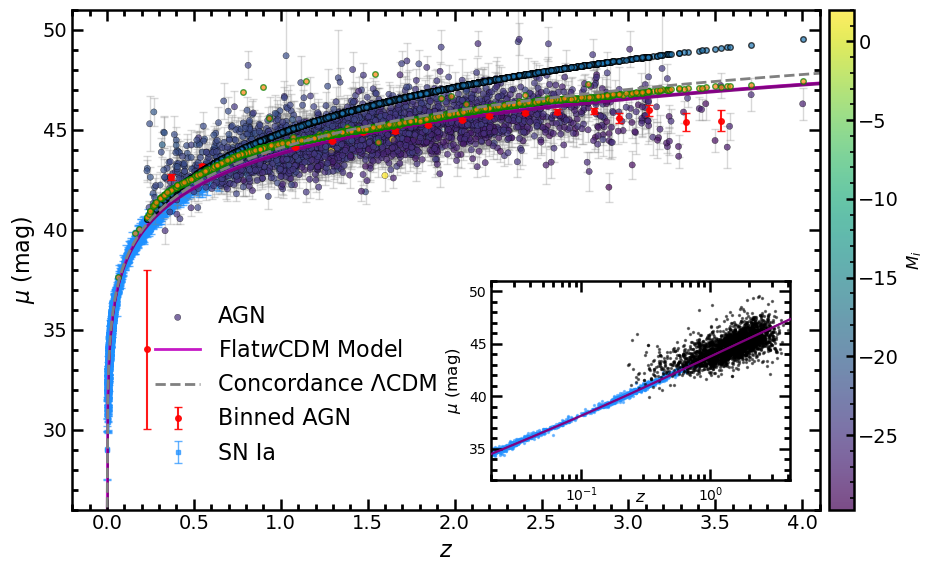

In [5]:
residuals, mu_pred_median, mu_pred_std = plot_hubble(flat_samples, df_agn, df_pantheon, cosmo_model=cosmo_model, show=True, show_true=True)

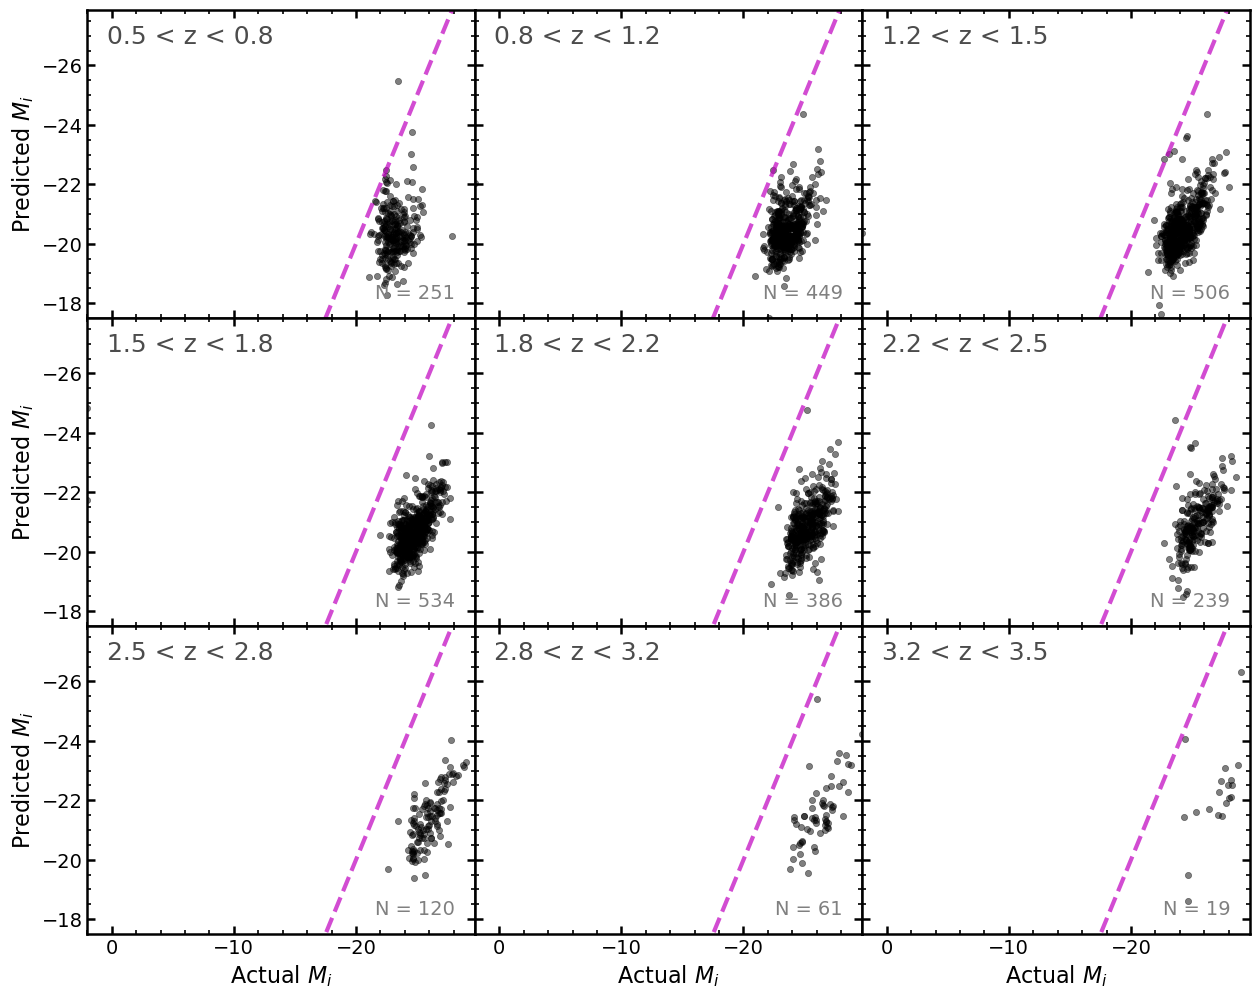

In [6]:
from hubble_plotting import plot_predicted_vs_actual_Mi

plot_predicted_vs_actual_Mi(flat_samples, df_agn, cosmo_model, show=True)